## Import liabraires
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Loading of the Dataset

In [184]:
df = pd.read_csv(r'C:\Users\ADMIN\Desktop\Jupyter folder/Downloads/50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [139]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [140]:
df.shape

(50, 5)

## Data Preprocessing

## Handling missing values

In [141]:
print('Number of missing values in the dataset :\n',df.isnull().sum())

Number of missing values in the dataset :
 R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


## Duplicate values

In [142]:
print('Number of duplicates values in the dataset :\n',df.duplicated().value_counts())

Number of duplicates values in the dataset :
 False    50
Name: count, dtype: int64


## Data Analysis

## Number of Startup data under the state.

In [143]:
state_wise = df['State'].value_counts()
print('Number of Startup under the State wise :\n',state_wise)

Number of Startup under the State wise :
 State
New York      17
California    17
Florida       16
Name: count, dtype: int64


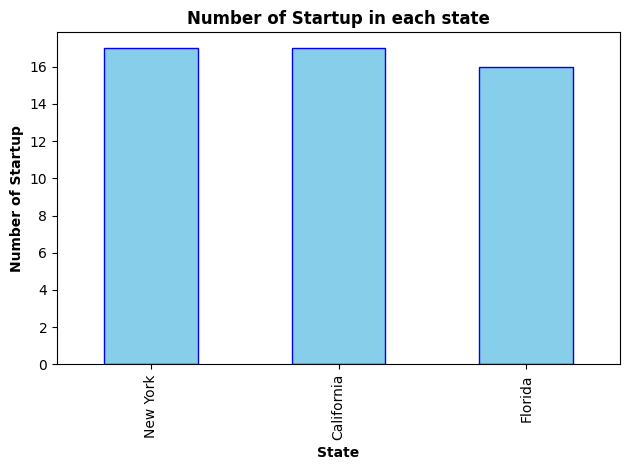

In [144]:
state_wise.plot(kind='bar', color='skyblue', edgecolor='blue')
plt.xlabel('State',fontweight='bold')
plt.ylabel('Number of Startup',fontweight='bold')
plt.title('Number of Startup in each state',fontweight='bold')
plt.tight_layout()
plt.show()

## Observation
- **The Above dataset**, **New york** & **California** was got higher.

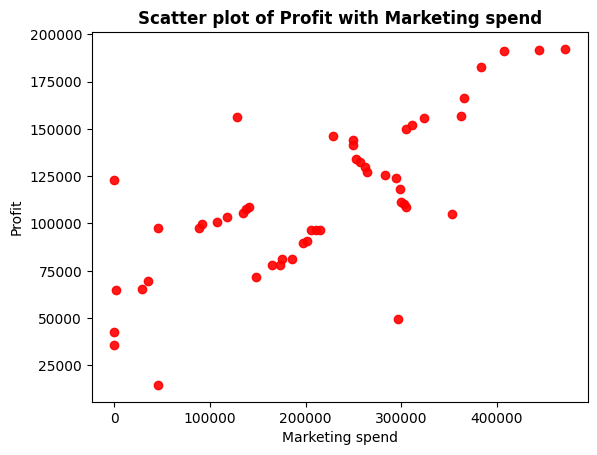

In [182]:
plt.scatter(df['Marketing Spend'], df['Profit'], color='red', alpha=0.9)
plt.title('Scatter plot of Profit with Marketing spend',fontweight='bold')
plt.xlabel('Marketing spend')
plt.ylabel('Profit')
plt.show()

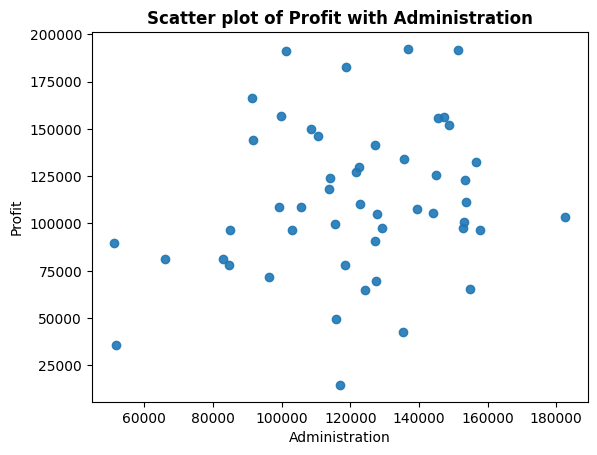

In [179]:
plt.scatter(df['Administration'], df['Profit'], alpha=0.9)
plt.title('Scatter plot of Profit with Administration',fontweight='bold')
plt.xlabel('Administration')
plt.ylabel('Profit')
plt.show()

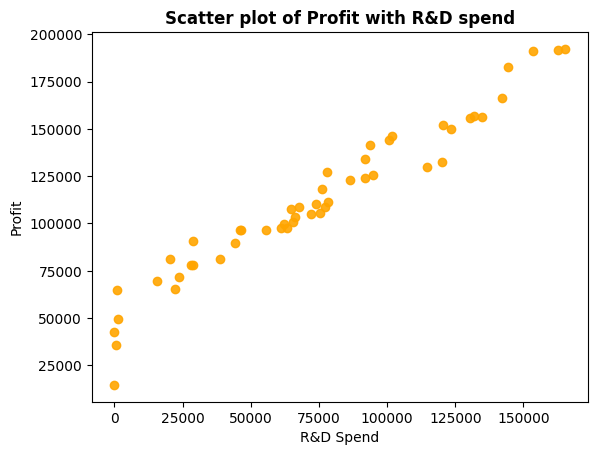

In [181]:
plt.scatter(df['R&D Spend'], df['Profit'], color='orange', alpha=0.9)
plt.title('Scatter plot of Profit with R&D spend',fontweight='bold')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.show()

Text(0, 0.5, 'Profit')

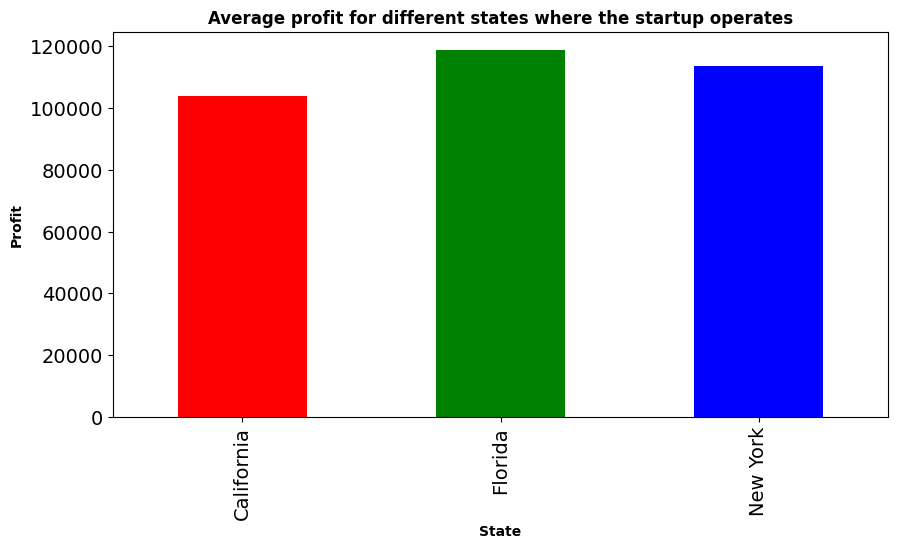

In [185]:
colors = ['red','green','blue']
ds = df.groupby(['State'])['Profit'].mean().plot.bar(figsize=(10,5), fontsize=14, color=colors)
ds.set_title('Average profit for different states where the startup operates',fontweight='bold',fontsize=12)
ds.set_xlabel('State',fontweight='bold',fontsize=10)
ds.set_ylabel('Profit',fontweight='bold',fontsize=10)

In [186]:
df['California_State'] = np.where(df['State']=='California',1,0)
df['New York_State'] = np.where(df['State']=='New York',1,0)
df['Florida_State'] = np.where(df['State']=='Florida',1,0)

## Dropping the State column

In [187]:
df.drop(['State'],axis=1,inplace=True)
df

,R&D Spend,Administration,Marketing Spend,Profit,California_State,New York_State,Florida_State
0,165349.20,136897.80,471784.10,192261.83,0,1,0
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,0,1
3,144372.41,118671.85,383199.62,182901.99,0,1,0
4,142107.34,91391.77,366168.42,166187.94,0,0,1
5,131876.90,99814.71,362861.36,156991.12,0,1,0
6,134615.46,147198.87,127716.82,156122.51,1,0,0
7,130298.13,145530.06,323876.68,155752.60,0,0,1
8,120542.52,148718.95,311613.29,152211.77,0,1,0
9,123334.88,108679.17,304981.62,149759.96,1,0,0


## Dependent and Independent (x and y)

In [188]:
dependent_variable = 'Profit'

In [189]:
independent_variable = list(set(df.columns.tolist())-{dependent_variable})
independent_variable

['Florida_State',
 'Marketing Spend',
 'New York_State',
 'R&D Spend',
 'California_State',
 'Administration']

In [190]:
x = df[independent_variable].values
y = df[dependent_variable].values

In [191]:
df[independent_variable]

,Florida_State,Marketing Spend,New York_State,R&D Spend,California_State,Administration
0,0,471784.10,1,165349.20,0,136897.80
1,0,443898.53,0,162597.70,1,151377.59
2,1,407934.54,0,153441.51,0,101145.55
3,0,383199.62,1,144372.41,0,118671.85
4,1,366168.42,0,142107.34,0,91391.77
5,0,362861.36,1,131876.90,0,99814.71
6,0,127716.82,0,134615.46,1,147198.87
7,1,323876.68,0,130298.13,0,145530.06
8,0,311613.29,1,120542.52,0,148718.95
9,0,304981.62,0,123334.88,1,108679.17


## Splitting data into Training and Testing

In [192]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [193]:
x_train[0:10]

array([[1.0000000e+00, 2.1463481e+05, 0.0000000e+00, 5.5493950e+04,
        0.0000000e+00, 1.0305749e+05],
       [0.0000000e+00, 2.0551764e+05, 1.0000000e+00, 4.6014020e+04,
        0.0000000e+00, 8.5047440e+04],
       [1.0000000e+00, 1.3405007e+05, 0.0000000e+00, 7.5328870e+04,
        0.0000000e+00, 1.4413598e+05],
       [0.0000000e+00, 2.1079767e+05, 0.0000000e+00, 4.6426070e+04,
        1.0000000e+00, 1.5769392e+05],
       [1.0000000e+00, 2.9491957e+05, 0.0000000e+00, 9.1749160e+04,
        0.0000000e+00, 1.1417579e+05],
       [1.0000000e+00, 3.2387668e+05, 0.0000000e+00, 1.3029813e+05,
        0.0000000e+00, 1.4553006e+05],
       [1.0000000e+00, 2.5651292e+05, 0.0000000e+00, 1.1994324e+05,
        0.0000000e+00, 1.5654742e+05],
       [0.0000000e+00, 1.9039300e+03, 1.0000000e+00, 1.0002300e+03,
        0.0000000e+00, 1.2415304e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 5.4205000e+02,
        0.0000000e+00, 5.1743150e+04],
       [0.0000000e+00, 1.0713838e+05,

In [163]:
# Transforming data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [164]:
x_train[0:10]

array([[0.45494286, 0.        , 1.        , 0.33561668, 0.        ,
        0.48655174],
       [0.43561799, 0.        , 0.        , 0.2782839 , 1.        ,
        0.3173015 ],
       [0.28413435, 0.        , 1.        , 0.45557444, 0.        ,
        0.87258866],
       [0.44680961, 1.        , 0.        , 0.2807759 , 0.        ,
        1.        ],
       [0.62511553, 0.        , 1.        , 0.55488118, 0.        ,
        0.59103645],
       [0.68649342, 0.        , 1.        , 0.7880179 , 0.        ,
        0.88568959],
       [0.54370828, 0.        , 1.        , 0.72539353, 0.        ,
        0.98922572],
       [0.0040356 , 0.        , 0.        , 0.0060492 , 1.        ,
        0.6847981 ],
       [0.        , 0.        , 0.        , 0.00327821, 1.        ,
        0.00432296],
       [0.22709197, 0.        , 0.        , 0.39676926, 1.        ,
        0.95618996]])

## Linear Regression model

In [165]:
model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [166]:
model.intercept_

np.float64(44153.95466784859)

In [167]:
model.coef_

array([ 1.72720281e+04,  8.66383692e+01, -8.72645791e+02,  1.27892182e+05,
        7.86007422e+02,  3.49927567e+03])

In [169]:
# Prediction
y_pred_train = model.predict(x_train)

In [194]:
y_pred_train

array([ 95764.42320496,  89164.62849777, 109506.72329085,  91366.2188941 ,
       127111.48666646, 159019.04337114, 148905.9881254 ,  48179.60744028,
        45374.34722508, 102951.9596798 , 145449.63178399,  96684.71387299,
        97535.3576194 , 116571.15139254,  69421.13311312, 116212.62095133,
        60736.53267612, 152787.95464277, 127413.0337311 , 102210.16391827,
       161822.7226407 , 131583.61511491,  75019.09161337,  48054.91969394,
       189547.28196893, 127528.92248422,  85540.50570954, 111255.8251405 ,
       156191.10124356, 108464.25100331,  75306.81185049, 119915.38726755,
       115144.58914955, 152688.90677959,  81513.47163492,  57298.28613018,
       172852.28336637, 192919.57537462,  47007.62737751,  65835.99435878])

In [170]:
y_train

array([ 96778.92,  96479.51, 105733.54,  96712.8 , 124266.9 , 155752.6 ,
       132602.65,  64926.08,  35673.41, 101004.64, 129917.04,  99937.59,
        97427.84, 126992.93,  71498.49, 118474.03,  69758.98, 152211.77,
       134307.35, 107404.34, 156991.12, 125370.37,  78239.91,  14681.4 ,
       191792.06, 141585.52,  89949.14, 108552.04, 156122.51, 108733.99,
        90708.19, 111313.02, 122776.86, 149759.96,  81005.76,  49490.75,
       182901.99, 192261.83,  42559.73,  65200.33])

In [171]:
y_pred = model.predict(x_test)
y_pred

array([103015.20159796, 132582.27760816, 132447.73845174,  71976.09851258,
       178537.48221055, 116161.24230165,  67851.69209676,  98791.73374687,
       113969.43533012, 167921.0656955 ])

In [172]:
y_test

array([103282.38, 144259.4 , 146121.95,  77798.83, 191050.39, 105008.31,
        81229.06,  97483.56, 110352.25, 166187.94])

In [198]:
# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
print('Mean Squared Error :\n',mean_squared_error(y_test,y_pred))
print('R2 Score :\n',r2_score(y_test,y_pred))

Mean Squared Error :
 83502864.03257722
R2 Score :
 0.9347068473282426


In [174]:
rmse_train = np.sqrt(mean_squared_error(y_train,y_pred_train))
print('RMSE (Train) : ',rmse_train)
rmse_test = np.sqrt(mean_squared_error(y_test,y_pred))
print('RMSE (Test) : ',rmse_test)

RMSE (Train) :  9031.666612578969
RMSE (Test) :  9137.990152794935


In [175]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print('Mean Absolute Error : ',mae)

Mean Absolute Error :  7514.2936596406025


In [176]:
r2_test = r2_score(y_test,y_pred)
r2_train = r2_score(y_train,y_pred_train)
print('R2 Score of Test : ',r2_test)
print('R2 Score of Train : ',r2_train)

R2 Score of Test :  0.9347068473282426
R2 Score of Train :  0.9501847627493607
